EXPERIMENT 5.3: Prior Sensitivity and Practical Branch Disambiguation
S0=100.0, K=160.0, sigma=0.2, r=0.05, T=1.0, B=64
V_BS=0.158954, V_disc=0.677644
Encoded p_true=0.013021
theta_a (single-angle)=0.114358, k_crit=13.24
shots=8192, trials=30
k values=[7, 15, 31, 63]

------------------------------------------------------------------------------------------
Depth k=7  (branch spacing in θ: 0.209440 rad)
  eps=-30.0%: p_prior=0.009115, offset=0.18 branches, error=0.208945±0.000644, wrong-branch=100%
  eps=-20.0%: p_prior=0.010417, offset=0.12 branches, error=0.209110±0.000613, wrong-branch=100%
  eps=-15.0%: p_prior=0.011068, offset=0.09 branches, error=0.003134±0.000369, wrong-branch=0%
  eps=-10.0%: p_prior=0.011719, offset=0.06 branches, error=0.003038±0.000345, wrong-branch=0%
  eps=-7.5%: p_prior=0.012044, offset=0.04 branches, error=0.003087±0.000385, wrong-branch=0%
  eps=-5.0%: p_prior=0.012370, offset=0.03 branches, error=0.003772±0.000465, wrong-branch=0%
  eps=-2.5%: p_prior=

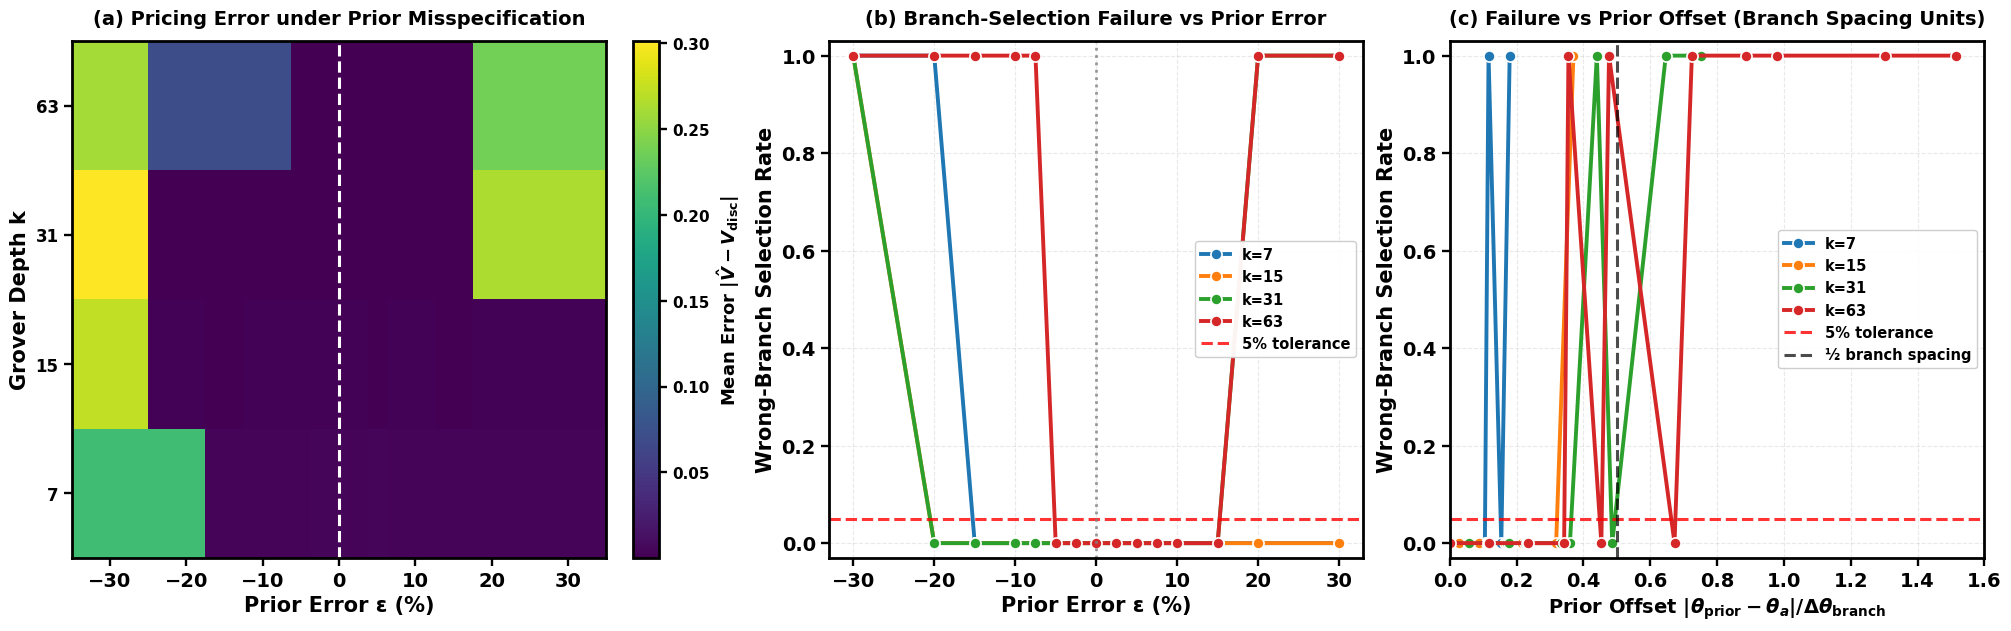


Saved: experiment_5_3_prior_sensitivity.pdf / .png


In [5]:
# ==============================================================================
# EXPERIMENT 5.3: Prior Sensitivity and Practical Branch Disambiguation
#
# Purpose:
#   Test how robust corrected branch-aware QAE remains when the disambiguation
#   prior is no longer the exact encoded probability p_true.
#
# Core idea:
#   Candidate generation is mathematically correct, but branch selection depends
#   on the prior. At high Grover depth, candidate spacing shrinks, so imperfect
#   priors can trigger wrong-branch selection. The failure threshold should occur
#   when the prior error exceeds approximately half a branch spacing.
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from qiskit import QuantumCircuit
from qiskit_aer.primitives import Sampler

sampler = Sampler()

# ==============================================================================
# HELPER FUNCTIONS
# ==============================================================================

def black_scholes_call(S0, K, r, sigma, T):
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S0 * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)


def build_discrete_problem(S0, K, r, sigma, T, B=64, q_low=1e-6, q_high=1-1e-6):
    mu_log = np.log(S0) + (r - 0.5*sigma**2)*T
    sigma_log = sigma * np.sqrt(T)

    quantiles = np.linspace(q_low, q_high, B+1)
    log_edges = norm.ppf(quantiles, loc=mu_log, scale=sigma_log)
    edges = np.exp(log_edges)

    centers = np.sqrt(edges[:-1] * edges[1:])
    cdf_edges = norm.cdf(log_edges, loc=mu_log, scale=sigma_log)

    probs = np.diff(cdf_edges)
    probs /= probs.sum()

    payoffs = np.maximum(centers - K, 0)
    V_disc = np.exp(-r*T) * np.sum(probs * payoffs)

    max_payoff = payoffs.max()
    C = max_payoff * 1.2
    p = V_disc / (np.exp(-r*T) * C)

    if p > 0.25:
        C = V_disc / (np.exp(-r*T) * 0.20)
        p = 0.20

    return type("Problem", (object,), {
        "V_disc": V_disc,
        "p": p,
        "C": C,
        "max_payoff": max_payoff,
        "centers": centers,
        "probs": probs,
        "payoffs": payoffs
    })()


def run_QAE_with_prior(p_true, p_prior, k, shots, prob, r, T):
    """
    Corrected branch-aware QAE with imperfect prior.

    Circuit measures:
        P_k = sin^2((2k+1) * theta_a) under the θ = 2θ_a convention used here.

    The two alias families in θ-space (θ = 2θ_a, valid range [0, π]):
        Family A: θ = (angle_measured + 2π·m) / (2k+1)
        Family B: θ = (2π - angle_measured + 2π·m) / (2k+1)
    for m = 0, 1, ..., k. Only candidates with θ ∈ [0, π] correspond to
    valid amplitudes; the rest are duplicates or out-of-range.

    Branch selection uses p_prior, not p_true. A wrong-branch event is
    defined as the selected candidate lying more than half a branch
    spacing away from the true θ_a in θ-space.
    """

    theta_true = 2.0 * np.arcsin(np.sqrt(np.clip(p_true, 0.0, 1.0)))
    total_angle = (2*k + 1) * theta_true

    qc = QuantumCircuit(1, 1)
    qc.ry(total_angle, 0)
    qc.measure(0, 0)

    result = sampler.run([qc], shots=shots).result()
    p_k_measured = result.quasi_dists[0].get(1, 0.0)

    val = np.sqrt(np.clip(p_k_measured, 0.0, 1.0))
    angle_measured = 2.0 * np.arcsin(val)

    # Generate candidates in θ-space, restricted to [0, π]
    candidate_thetas = []
    candidate_ps = []

    for m in range(k + 1):
        theta_pos = (angle_measured + 2.0*np.pi*m) / (2*k + 1)
        if 0.0 <= theta_pos <= np.pi:
            candidate_thetas.append(theta_pos)
            candidate_ps.append(np.sin(theta_pos / 2.0)**2)

        theta_neg = ((2.0*np.pi - angle_measured) + 2.0*np.pi*m) / (2*k + 1)
        if 0.0 <= theta_neg <= np.pi:
            candidate_thetas.append(theta_neg)
            candidate_ps.append(np.sin(theta_neg / 2.0)**2)

    # Deduplicate (very close candidates from numerical edge cases)
    unique = {}
    for th, p in zip(candidate_thetas, candidate_ps):
        key = round(th, 10)
        if key not in unique:
            unique[key] = (th, p)
    candidate_thetas = [v[0] for v in unique.values()]
    candidate_ps = [v[1] for v in unique.values()]

    # Branch selection: arg min |p_candidate - p_prior|
    idx_selected = min(
        range(len(candidate_ps)),
        key=lambda i: abs(candidate_ps[i] - p_prior)
    )
    selected_p = candidate_ps[idx_selected]
    selected_theta = candidate_thetas[idx_selected]
    
    V_hat = selected_p * prob.C * np.exp(-r*T)
    failure_threshold = 0.05 * prob.V_disc
    wrong_branch = abs(V_hat - prob.V_disc) > failure_threshold

    return selected_p, selected_theta, wrong_branch


# ==============================================================================
# EXPERIMENT PARAMETERS
# ==============================================================================

S0 = 100.0
K = 160.0
r = 0.05
sigma = 0.20
T = 1.0
B = 64

shots = 8192
n_trials = 30

k_values = [7, 15, 31, 63]
epsilons = np.array([
    -0.30, -0.20, -0.15, -0.10, -0.075, -0.05, -0.025,
     0.00,
     0.025, 0.05, 0.075, 0.10, 0.15, 0.20, 0.30
])

prob = build_discrete_problem(S0, K, r, sigma, T, B)
V_BS = black_scholes_call(S0, K, r, sigma, T)

theta_a_true = 2.0 * np.arcsin(np.sqrt(prob.p))   # in θ = 2θ_a convention
k_crit = np.pi / (2 * np.arcsin(np.sqrt(prob.p))) - 0.5

print("="*90)
print("EXPERIMENT 5.3: Prior Sensitivity and Practical Branch Disambiguation")
print("="*90)
print(f"S0={S0}, K={K}, sigma={sigma}, r={r}, T={T}, B={B}")
print(f"V_BS={V_BS:.6f}, V_disc={prob.V_disc:.6f}")
print(f"Encoded p_true={prob.p:.6f}")
print(f"theta_a (single-angle)={np.arcsin(np.sqrt(prob.p)):.6f}, k_crit={k_crit:.2f}")
print(f"shots={shots}, trials={n_trials}")
print(f"k values={k_values}")
print("="*90)

# ==============================================================================
# RUN PRIOR SENSITIVITY SWEEP
# ==============================================================================

mean_price_error = np.zeros((len(k_values), len(epsilons)))
sem_price_error = np.zeros((len(k_values), len(epsilons)))
wrong_branch_rate = np.zeros((len(k_values), len(epsilons)))
mean_selected_p = np.zeros((len(k_values), len(epsilons)))
prior_offset_in_branches = np.zeros((len(k_values), len(epsilons)))

records = []

for i, k in enumerate(k_values):
    branch_spacing_theta = np.pi / (2*k + 1)

    print("\n" + "-"*90)
    print(f"Depth k={k}  (branch spacing in θ: {branch_spacing_theta:.6f} rad)")

    for j, eps in enumerate(epsilons):
        p_prior = prob.p * (1.0 + eps)
        p_prior = np.clip(p_prior, 1e-12, 1.0 - 1e-12)

        # Express prior offset in branch-spacing units (θ-space)
        theta_prior = 2.0 * np.arcsin(np.sqrt(p_prior))
        offset_theta = abs(theta_prior - theta_a_true)
        offset_branches = offset_theta / branch_spacing_theta
        prior_offset_in_branches[i, j] = offset_branches

        trial_errors = []
        wrong_count = 0
        selected_ps = []

        for trial in range(n_trials):
            p_hat, theta_hat, wrong_branch = run_QAE_with_prior(
                p_true=prob.p,
                p_prior=p_prior,
                k=k,
                shots=shots,
                prob=prob,
                r=r,
                T=T
            )

            V_hat = p_hat * prob.C * np.exp(-r*T)
            err = abs(V_hat - prob.V_disc)

            trial_errors.append(err)
            selected_ps.append(p_hat)
            wrong_count += int(wrong_branch)

        mean_err = np.mean(trial_errors)
        sem_err = np.std(trial_errors, ddof=1) / np.sqrt(n_trials)
        fail_rate = wrong_count / n_trials
        mean_p_hat = np.mean(selected_ps)

        mean_price_error[i, j] = mean_err
        sem_price_error[i, j] = sem_err
        wrong_branch_rate[i, j] = fail_rate
        mean_selected_p[i, j] = mean_p_hat

        records.append({
            "k": k,
            "epsilon": eps,
            "p_prior": p_prior,
            "offset_branches": offset_branches,
            "mean_error": mean_err,
            "sem_error": sem_err,
            "wrong_branch_rate": fail_rate,
            "mean_p_hat": mean_p_hat
        })

        print(
            f"  eps={eps:+.1%}: "
            f"p_prior={p_prior:.6f}, "
            f"offset={offset_branches:.2f} branches, "
            f"error={mean_err:.6f}±{sem_err:.6f}, "
            f"wrong-branch={fail_rate:.0%}"
        )

# ==============================================================================
# SUMMARY: PRIOR TOLERANCE BY DEPTH
# ==============================================================================

print("\n" + "="*90)
print("PRIOR TOLERANCE SUMMARY")
print("="*90)
print(f"{'k':<6}{'safe eps range (<5% wrong-branch)':<40}{'safe offset (branches)':<26}{'min err':<10}")
print("-"*90)

for i, k in enumerate(k_values):
    safe_mask = wrong_branch_rate[i, :] < 0.05

    if np.any(safe_mask):
        safe_eps = epsilons[safe_mask]
        safe_offsets = prior_offset_in_branches[i, safe_mask]
        safe_range = f"{safe_eps.min():+.1%} to {safe_eps.max():+.1%}"
        safe_offset_str = f"up to {safe_offsets.max():.2f}"
    else:
        safe_range = "none"
        safe_offset_str = "n/a"

    print(
        f"{k:<6}"
        f"{safe_range:<40}"
        f"{safe_offset_str:<26}"
        f"{mean_price_error[i, :].min():<10.6f}"
    )

print("="*90)

# ==============================================================================
# PLOTTING
# ==============================================================================

plt.rcParams.update({
    "font.size": 14,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.linewidth": 2.0,
    "xtick.major.width": 1.7,
    "ytick.major.width": 1.7,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "legend.fontsize": 11,
})

fig, axes = plt.subplots(1, 3, figsize=(20, 6.2), constrained_layout=True)

# ------------------------------------------------------------------------------
# Panel A: Heatmap of pricing error vs (ε, k)
# ------------------------------------------------------------------------------

ax = axes[0]

# Use pcolormesh for cleaner non-uniform axis handling
X_edges = np.concatenate([
    [epsilons[0] - (epsilons[1] - epsilons[0]) / 2],
    (epsilons[:-1] + epsilons[1:]) / 2,
    [epsilons[-1] + (epsilons[-1] - epsilons[-2]) / 2]
]) * 100

Y_edges = np.arange(len(k_values) + 1) - 0.5

im = ax.pcolormesh(
    X_edges, Y_edges, mean_price_error,
    cmap="viridis", shading="flat"
)

ax.set_yticks(np.arange(len(k_values)))
ax.set_yticklabels([str(k) for k in k_values], fontsize=12, fontweight="bold")
ax.set_xlabel("Prior Error ε (%)", fontsize=15, fontweight="bold")
ax.set_ylabel("Grover Depth k", fontsize=15, fontweight="bold")
ax.set_title("(a) Pricing Error under Prior Misspecification",
             fontsize=14, fontweight="bold", pad=12)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"Mean Error $|\hat{V}-V_{\mathrm{disc}}|$",
               fontsize=13, fontweight="bold")
cbar.ax.tick_params(labelsize=11)

ax.axvline(0, color="white", linewidth=2.2, linestyle="--")

# ------------------------------------------------------------------------------
# Panel B: Wrong-branch rate vs ε
# ------------------------------------------------------------------------------

ax = axes[1]

for i, k in enumerate(k_values):
    ax.plot(
        epsilons*100,
        wrong_branch_rate[i, :],
        "o-",
        linewidth=2.8,
        markersize=8,
        markeredgecolor="white",
        markeredgewidth=1.2,
        label=f"k={k}"
    )

ax.axhline(0.05, color="red", linestyle="--", linewidth=2.2, alpha=0.8,
           label="5% tolerance")
ax.axvline(0, color="gray", linestyle=":", linewidth=2.0, alpha=0.8)

ax.set_xlabel("Prior Error ε (%)", fontsize=15, fontweight="bold")
ax.set_ylabel("Wrong-Branch Selection Rate", fontsize=15, fontweight="bold")
ax.set_title("(b) Branch-Selection Failure vs Prior Error",
             fontsize=14, fontweight="bold", pad=12)
ax.set_ylim(-0.03, 1.03)
ax.grid(True, linestyle="--", alpha=0.28)
ax.legend(fontsize=10.5, framealpha=0.95, loc="best")

# ------------------------------------------------------------------------------
# Panel C: Wrong-branch rate vs prior offset in branch-spacing units
# ------------------------------------------------------------------------------

ax = axes[2]

for i, k in enumerate(k_values):
    # Sort by offset for clean plotting
    order = np.argsort(prior_offset_in_branches[i, :])
    x = prior_offset_in_branches[i, order]
    y = wrong_branch_rate[i, order]

    ax.plot(
        x, y,
        "o-",
        linewidth=2.8,
        markersize=8,
        markeredgecolor="white",
        markeredgewidth=1.2,
        label=f"k={k}"
    )

ax.axhline(0.05, color="red", linestyle="--", linewidth=2.2, alpha=0.8,
           label="5% tolerance")
ax.axvline(0.5, color="black", linestyle="--", linewidth=2.2, alpha=0.7,
           label="½ branch spacing")

ax.set_xlabel(r"Prior Offset $|\theta_{\mathrm{prior}}-\theta_a| / \Delta\theta_{\mathrm{branch}}$",
              fontsize=14, fontweight="bold")
ax.set_ylabel("Wrong-Branch Selection Rate", fontsize=15, fontweight="bold")
ax.set_title("(c) Failure vs Prior Offset (Branch Spacing Units)",
             fontsize=14, fontweight="bold", pad=12)
ax.set_ylim(-0.03, 1.03)
ax.grid(True, linestyle="--", alpha=0.28)
ax.legend(fontsize=10.5, framealpha=0.95, loc="best")
ax.set_xlim(0, 1.6)

plt.savefig("experiment_5_3_prior_sensitivity.pdf", bbox_inches="tight")
plt.savefig("experiment_5_3_prior_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved: experiment_5_3_prior_sensitivity.pdf / .png")